# Mental Health in Tech — Preprocessing

**Goal:** Clean, standardize, and merge the 2014 and 2016 datasets into one clean dataset ready for modeling.

---
## Table of Contents
1. Import Libraries
2. Load Datasets
3. Clean 2014 Dataset
4. Clean 2016 Dataset
5. Merge Datasets
6. Feature Engineering
7. Encoding
8. Train/Test Split
9. Save Cleaned Dataset

## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries loaded!')

Libraries loaded!


## 2. Load Datasets

In [3]:
df14 = pd.read_csv(r"C:\Users\hp\Desktop\Mental health in tech\survey.csv")
df16 = pd.read_csv(r"C:\Users\hp\Desktop\Mental health in tech\mental-heath-in-tech-2016_20161114.csv")

print(f'2014: {df14.shape}')
print(f'2016: {df16.shape}')

2014: (1259, 27)
2016: (1433, 63)


## 3. Clean 2014 Dataset

Issues found in EDA:
- `Age` has extreme outliers (negative values, 99999999999)
- `Gender` has 49 unique raw values → standardize to Male/Female/Other
- `work_interfere` has 264 missing values → impute with mode
- `self_employed` has 18 missing values → impute with mode
- `state`, `comments`, `Timestamp` → drop (not useful for modeling)

In [4]:
# --- Step 1: Drop irrelevant columns ---
df14_clean = df14.drop(columns=['Timestamp', 'state', 'comments']).copy()
print('Dropped: Timestamp, state, comments')
print(f'Shape after drop: {df14_clean.shape}')

Dropped: Timestamp, state, comments
Shape after drop: (1259, 24)


In [5]:
# --- Step 2: Clean Age ---
print('Before cleaning:')
print(f'  Age range: {df14_clean["Age"].min()} to {df14_clean["Age"].max()}')
print(f'  Outliers < 15: {(df14_clean["Age"] < 15).sum()}')
print(f'  Outliers > 80: {(df14_clean["Age"] > 80).sum()}')

df14_clean = df14_clean[(df14_clean['Age'] >= 15) & (df14_clean['Age'] <= 80)].copy()

print('\nAfter cleaning:')
print(f'  Age range: {df14_clean["Age"].min()} to {df14_clean["Age"].max()}')
print(f'  Remaining rows: {len(df14_clean)}')

Before cleaning:
  Age range: -1726 to 99999999999
  Outliers < 15: 6
  Outliers > 80: 2

After cleaning:
  Age range: 18 to 72
  Remaining rows: 1251


In [6]:
# --- Step 3: Standardize Gender ---
def standardize_gender(gender):
    if pd.isna(gender):
        return 'Other'
    g = str(gender).lower().strip()
    male_kw = ['male', 'm', 'man', 'cis male', 'cis man', 'maile', 'mal',
                'make', 'mail', 'malr', 'msle', 'male-ish', 'male (cis)']
    female_kw = ['female', 'f', 'woman', 'cis female', 'cis woman',
                  'femake', 'femail', 'femmale']
    if g in male_kw:
        return 'Male'
    elif g in female_kw:
        return 'Female'
    else:
        return 'Other'

df14_clean['Gender'] = df14_clean['Gender'].apply(standardize_gender)

print('Gender after standardization:')
print(df14_clean['Gender'].value_counts())

Gender after standardization:
Gender
Male      986
Female    245
Other      20
Name: count, dtype: int64


In [7]:
# --- Step 4: Impute missing values ---
print('Missing values before imputation:')
print(df14_clean.isnull().sum()[df14_clean.isnull().sum() > 0])

# work_interfere: impute with mode (most common value)
mode_wi = df14_clean['work_interfere'].mode()[0]
df14_clean['work_interfere'] = df14_clean['work_interfere'].fillna(mode_wi)
print(f'\nwork_interfere imputed with mode: "{mode_wi}"')

# self_employed: impute with mode
mode_se = df14_clean['self_employed'].mode()[0]
df14_clean['self_employed'] = df14_clean['self_employed'].fillna(mode_se)
print(f'self_employed imputed with mode: "{mode_se}"')

print('\nMissing values after imputation:')
print(df14_clean.isnull().sum()[df14_clean.isnull().sum() > 0])
print('No missing values!' if df14_clean.isnull().sum().sum() == 0 else '')

Missing values before imputation:
self_employed      18
work_interfere    262
dtype: int64

work_interfere imputed with mode: "Sometimes"
self_employed imputed with mode: "No"

Missing values after imputation:
Series([], dtype: int64)
No missing values!


In [8]:
# --- Step 5: Encode target variable ---
df14_clean['treatment'] = df14_clean['treatment'].map({'Yes': 1, 'No': 0})
print('Target variable encoded: Yes→1, No→0')
print(df14_clean['treatment'].value_counts())

Target variable encoded: Yes→1, No→0
treatment
1    632
0    619
Name: count, dtype: int64


In [9]:
# --- Step 6: Add year column ---
df14_clean['year'] = 2014
print('Added year=2014 column')
print(f'Final 2014 shape: {df14_clean.shape}')

Added year=2014 column
Final 2014 shape: (1251, 25)


## 4. Clean 2016 Dataset

The 2016 dataset has 63 columns with long question-style names.
We will:
- Select only columns that match 2014 features
- Rename them to match 2014 column names
- Standardize values to match 2014 format
- Handle missing values

In [10]:
# --- Step 1: Select and rename relevant columns ---
col_map_16 = {
    'What is your age?':                                                                        'Age',
    'What is your gender?':                                                                     'Gender',
    'What country do you live in?':                                                             'Country',
    'Are you self-employed?':                                                                   'self_employed',
    'Do you have a family history of mental illness?':                                          'family_history',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'work_interfere',
    'How many employees does your company or organization have?':                               'no_employees',
    'Do you work remotely?':                                                                    'remote_work',
    'Is your employer primarily a tech company/organization?':                                  'tech_company',
    'Does your employer provide mental health benefits as part of healthcare coverage?':        'benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'care_options',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'wellness_program',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?':      'coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'supervisor',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'phys_health_consequence',
    'Do you feel that your employer takes mental health as seriously as physical health?':      'mental_vs_physical',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?': 'obs_consequence',
    'Would you bring up a mental health issue with a potential employer in an interview?':      'mental_health_interview',
}

df16_clean = df16[list(col_map_16.keys())].rename(columns=col_map_16).copy()
print(f'Selected {len(df16_clean.columns)} columns from 2016')
print(f'Shape: {df16_clean.shape}')
print(df16_clean.head(3))

Selected 20 columns from 2016
Shape: (1433, 20)
   Age Gender                   Country  self_employed family_history  \
0   39   Male            United Kingdom              0             No   
1   29   male  United States of America              0            Yes   
2   38  Male             United Kingdom              0             No   

   treatment        work_interfere no_employees remote_work  tech_company  \
0          0  Not applicable to me       26-100   Sometimes           1.0   
1          1             Sometimes         6-25       Never           1.0   
2          1  Not applicable to me         6-25      Always           1.0   

                          benefits care_options wellness_program  \
0  Not eligible for coverage / N/A          NaN               No   
1                               No          Yes              Yes   
2                               No          NaN               No   

      anonymity coworkers supervisor phys_health_consequence  \
0  I don't kn

In [11]:
# --- Step 2: Clean Age ---
df16_clean = df16_clean[(df16_clean['Age'] >= 15) & (df16_clean['Age'] <= 80)].copy()
print(f'2016 rows after age cleaning: {len(df16_clean)}')

2016 rows after age cleaning: 1430


In [12]:
# --- Step 3: Standardize Gender ---
df16_clean['Gender'] = df16_clean['Gender'].apply(standardize_gender)
print('2016 Gender after standardization:')
print(df16_clean['Gender'].value_counts())

2016 Gender after standardization:
Gender
Male      1049
Female     330
Other       51
Name: count, dtype: int64


In [13]:
# --- Step 4: Standardize binary columns (0/1 → Yes/No) ---
# self_employed: 0→No, 1→Yes
df16_clean['self_employed'] = df16_clean['self_employed'].map({0: 'No', 1: 'Yes'})

# tech_company: 0.0→No, 1.0→Yes
df16_clean['tech_company'] = df16_clean['tech_company'].map({0.0: 'No', 1.0: 'Yes'})

# treatment: already 0/1 — keep as is
print('Binary columns standardized')
print('self_employed:', df16_clean['self_employed'].value_counts().to_dict())
print('tech_company:', df16_clean['tech_company'].value_counts().to_dict())

Binary columns standardized
self_employed: {'No': 1143, 'Yes': 287}
tech_company: {'Yes': 880, 'No': 263}


In [14]:
# --- Step 5: Standardize remote_work ---
# 2014: Yes/No   |   2016: Always/Sometimes/Never
print('2016 remote_work values:', df16_clean['remote_work'].value_counts().to_dict())
df16_clean['remote_work'] = df16_clean['remote_work'].map({
    'Always':    'Yes',
    'Sometimes': 'Yes',
    'Never':     'No'
})
print('After standardization:', df16_clean['remote_work'].value_counts().to_dict())

2016 remote_work values: {'Sometimes': 754, 'Always': 343, 'Never': 333}
After standardization: {'Yes': 1097, 'No': 333}


In [15]:
# --- Step 6: Standardize family_history ---
# 2014: Yes/No   |   2016: Yes/No/I don't know
print('2016 family_history values:', df16_clean['family_history'].value_counts().to_dict())
df16_clean['family_history'] = df16_clean['family_history'].map({
    'Yes':          'Yes',
    'No':           'No',
    "I don't know": 'No'   # conservative assumption
})
print('After standardization:', df16_clean['family_history'].value_counts().to_dict())

2016 family_history values: {'Yes': 668, 'No': 488, "I don't know": 274}
After standardization: {'No': 762, 'Yes': 668}


In [16]:
# --- Step 7: Standardize benefits ---
# 2014: Yes / No / Don't know
# 2016: Yes / No / I don't know / Not eligible...
print('2016 benefits values:', df16_clean['benefits'].value_counts().to_dict())
df16_clean['benefits'] = df16_clean['benefits'].map({
    'Yes':                                "Yes",
    'No':                                 "No",
    "I don't know":                       "Don't know",
    'Not eligible for coverage / N/A':    "Don't know"
})
print('After standardization:', df16_clean['benefits'].value_counts().to_dict())

2016 benefits values: {'Yes': 528, "I don't know": 319, 'No': 213, 'Not eligible for coverage / N/A': 83}
After standardization: {'Yes': 528, "Don't know": 402, 'No': 213}


In [17]:
# --- Step 8: Standardize work_interfere ---
# 2016 equivalent uses different scale — map to 2014 scale
print('2016 work_interfere values:', df16_clean['work_interfere'].value_counts().to_dict())
df16_clean['work_interfere'] = df16_clean['work_interfere'].map({
    'Often':              'Often',
    'Sometimes':          'Sometimes',
    'Rarely':             'Rarely',
    'Never':              'Never',
    'Not applicable to me': 'Never'
})
print('After standardization:', df16_clean['work_interfere'].value_counts().to_dict())

2016 work_interfere values: {'Often': 537, 'Not applicable to me': 467, 'Sometimes': 362, 'Rarely': 52, 'Never': 12}
After standardization: {'Often': 537, 'Never': 479, 'Sometimes': 362, 'Rarely': 52}


In [18]:
# --- Step 9: Handle missing values in 2016 ---
print('Missing values in 2016:')
missing = df16_clean.isnull().sum()
print(missing[missing > 0])

for col in df16_clean.columns:
    if df16_clean[col].isnull().sum() > 0:
        if df16_clean[col].dtype == 'object':
            mode_val = df16_clean[col].mode()[0]
            df16_clean[col] = df16_clean[col].fillna(mode_val)
            print(f'  {col}: imputed with mode="{mode_val}"')
        else:
            median_val = df16_clean[col].median()
            df16_clean[col] = df16_clean[col].fillna(median_val)
            print(f'  {col}: imputed with median={median_val}')

print('\nMissing values after imputation:', df16_clean.isnull().sum().sum())

Missing values in 2016:
no_employees               287
tech_company               287
benefits                   287
care_options               420
wellness_program           287
anonymity                  287
coworkers                  287
supervisor                 287
phys_health_consequence    287
mental_vs_physical         287
obs_consequence            775
dtype: int64
  no_employees: imputed with mode="26-100"
  tech_company: imputed with mode="Yes"
  benefits: imputed with mode="Yes"
  care_options: imputed with mode="No"
  wellness_program: imputed with mode="No"
  anonymity: imputed with mode="I don't know"
  coworkers: imputed with mode="Maybe"
  supervisor: imputed with mode="Yes"
  phys_health_consequence: imputed with mode="No"
  mental_vs_physical: imputed with mode="I don't know"
  obs_consequence: imputed with mode="Yes"

Missing values after imputation: 0


In [19]:
# --- Step 10: Add year and missing columns ---
df16_clean['year'] = 2016

# 2014 has these columns, 2016 doesn't → add with mode from 2014
missing_cols = ['seek_help', 'leave', 'mental_health_consequence', 'phys_health_interview']
for col in missing_cols:
    if col in df14_clean.columns:
        mode_val = df14_clean[col].mode()[0]
        df16_clean[col] = mode_val
        print(f'  Added {col} with value "{mode_val}" (from 2014 mode)')

print(f'\nFinal 2016 shape: {df16_clean.shape}')

  Added seek_help with value "No" (from 2014 mode)
  Added leave with value "Don't know" (from 2014 mode)
  Added mental_health_consequence with value "No" (from 2014 mode)
  Added phys_health_interview with value "Maybe" (from 2014 mode)

Final 2016 shape: (1430, 25)


## 5. Merge Datasets

In [20]:
# Align columns
common_cols = [col for col in df14_clean.columns if col in df16_clean.columns]
print(f'Common columns: {len(common_cols)}')
print(common_cols)

df_merged = pd.concat([
    df14_clean[common_cols],
    df16_clean[common_cols]
], ignore_index=True)

print(f'\nMerged dataset shape: {df_merged.shape}')
print(f'Year distribution:')
print(df_merged['year'].value_counts())

Common columns: 25
['Age', 'Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'year']

Merged dataset shape: (2681, 25)
Year distribution:
year
2016    1430
2014    1251
Name: count, dtype: int64


In [21]:
# Verify no missing values in merged dataset
print('Missing values in merged dataset:')
missing_merged = df_merged.isnull().sum()
if missing_merged.sum() == 0:
    print('  ✅ No missing values!')
else:
    print(missing_merged[missing_merged > 0])
    # Fill any remaining
    for col in df_merged.columns:
        if df_merged[col].isnull().sum() > 0:
            if df_merged[col].dtype == 'object':
                df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])
            else:
                df_merged[col] = df_merged[col].fillna(df_merged[col].median())
    print('  ✅ Remaining missing values filled!')

print(f'\nFinal merged shape: {df_merged.shape}')
df_merged.head()

Missing values in merged dataset:
  ✅ No missing values!

Final merged shape: (2681, 25)


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,year
0,37,Female,United States,No,No,1,Often,6-25,No,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,2014
1,44,Male,United States,No,No,0,Rarely,More than 1000,No,No,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,2014
2,32,Male,Canada,No,No,0,Rarely,6-25,No,Yes,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,2014
3,31,Male,United Kingdom,No,Yes,1,Often,26-100,No,Yes,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,2014
4,31,Male,United States,No,No,0,Never,100-500,Yes,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,2014


## 6. Feature Engineering

Age group distribution:
age_group
15-25     386
26-35    1441
36-45     672
46+       182
Name: count, dtype: int64


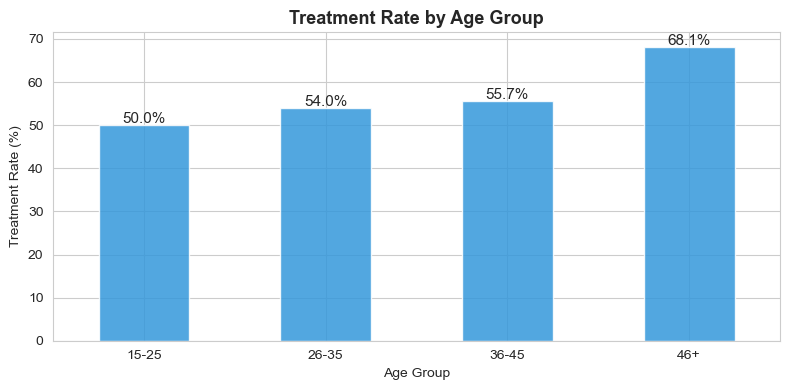

In [22]:
# Create age groups for better pattern recognition
df_merged['age_group'] = pd.cut(
    df_merged['Age'],
    bins=[14, 25, 35, 45, 80],
    labels=['15-25', '26-35', '36-45', '46+']
)

print('Age group distribution:')
print(df_merged['age_group'].value_counts().sort_index())

# Treatment rate by age group
age_treatment = df_merged.groupby('age_group', observed=True)['treatment'].mean() * 100

plt.figure(figsize=(8, 4))
age_treatment.plot(kind='bar', color='#3498db', alpha=0.85, edgecolor='white')
plt.title('Treatment Rate by Age Group', fontweight='bold', fontsize=13)
plt.ylabel('Treatment Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
for i, v in enumerate(age_treatment.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Encoding

In [23]:
# Show categorical columns and their unique values
cat_cols = df_merged.select_dtypes(include='object').columns.tolist()
cat_cols += ['age_group']  # categorical dtype
print('Categorical columns to encode:')
for col in cat_cols:
    print(f'  {col}: {df_merged[col].unique().tolist()}')

Categorical columns to encode:
  Gender: ['Female', 'Male', 'Other']
  Country: ['United States', 'Canada', 'United Kingdom', 'Bulgaria', 'France', 'Portugal', 'Netherlands', 'Switzerland', 'Poland', 'Australia', 'Germany', 'Russia', 'Mexico', 'Brazil', 'Slovenia', 'Costa Rica', 'Austria', 'Ireland', 'India', 'South Africa', 'Italy', 'Sweden', 'Colombia', 'Latvia', 'Romania', 'Belgium', 'New Zealand', 'Spain', 'Finland', 'Uruguay', 'Israel', 'Bosnia and Herzegovina', 'Hungary', 'Singapore', 'Japan', 'Nigeria', 'Croatia', 'Norway', 'Thailand', 'Denmark', 'Greece', 'Moldova', 'Georgia', 'China', 'Czech Republic', 'Philippines', 'United States of America', 'Lithuania', 'Venezuela', 'Argentina', 'Vietnam', 'Slovakia', 'Bangladesh', 'Algeria', 'Pakistan', 'Afghanistan', 'Other', 'Brunei', 'Iran', 'Ecuador', 'Chile', 'Guatemala', 'Taiwan', 'Serbia', 'Estonia']
  self_employed: ['No', 'Yes']
  family_history: ['No', 'Yes']
  work_interfere: ['Often', 'Rarely', 'Never', 'Sometimes']
  no_emplo

In [24]:
df_encoded = df_merged.copy()

le = LabelEncoder()
encoding_map = {}  # store for interpretability

for col in cat_cols:
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Encoding complete!')
print('\nEncoding map (first 3 columns):')
for col in list(encoding_map.keys())[:3]:
    print(f'  {col}: {encoding_map[col]}')

Encoding complete!

Encoding map (first 3 columns):
  Gender: {'Female': 0, 'Male': 1, 'Other': 2}
  Country: {'Afghanistan': 0, 'Algeria': 1, 'Argentina': 2, 'Australia': 3, 'Austria': 4, 'Bangladesh': 5, 'Belgium': 6, 'Bosnia and Herzegovina': 7, 'Brazil': 8, 'Brunei': 9, 'Bulgaria': 10, 'Canada': 11, 'Chile': 12, 'China': 13, 'Colombia': 14, 'Costa Rica': 15, 'Croatia': 16, 'Czech Republic': 17, 'Denmark': 18, 'Ecuador': 19, 'Estonia': 20, 'Finland': 21, 'France': 22, 'Georgia': 23, 'Germany': 24, 'Greece': 25, 'Guatemala': 26, 'Hungary': 27, 'India': 28, 'Iran': 29, 'Ireland': 30, 'Israel': 31, 'Italy': 32, 'Japan': 33, 'Latvia': 34, 'Lithuania': 35, 'Mexico': 36, 'Moldova': 37, 'Netherlands': 38, 'New Zealand': 39, 'Nigeria': 40, 'Norway': 41, 'Other': 42, 'Pakistan': 43, 'Philippines': 44, 'Poland': 45, 'Portugal': 46, 'Romania': 47, 'Russia': 48, 'Serbia': 49, 'Singapore': 50, 'Slovakia': 51, 'Slovenia': 52, 'South Africa': 53, 'Spain': 54, 'Sweden': 55, 'Switzerland': 56, 'Taiw

In [25]:
print('Final encoded dataset:')
print(df_encoded.head())
print(f'\nShape: {df_encoded.shape}')
print(f'Dtypes:')
print(df_encoded.dtypes)

Final encoded dataset:
   Age  Gender  Country  self_employed  family_history  treatment  \
0   37       0       60              0               0          1   
1   44       1       60              0               0          0   
2   32       1       11              0               0          0   
3   31       1       59              0               1          1   
4   31       1       60              0               0          0   

   work_interfere  no_employees  remote_work  tech_company  ...  \
0               1             4            0             1  ...   
1               2             5            0             0  ...   
2               2             4            0             1  ...   
3               1             2            0             1  ...   
4               0             1            1             1  ...   

   mental_health_consequence  phys_health_consequence  coworkers  supervisor  \
0                          1                        1          2           3   

## 8. Train/Test Split

In [26]:
X = df_encoded.drop(columns=['treatment'])
y = df_encoded['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples:  {len(df_encoded)}')
print(f'Training set:   {len(X_train)} ({len(X_train)/len(df_encoded)*100:.0f}%)')
print(f'Test set:       {len(X_test)} ({len(X_test)/len(df_encoded)*100:.0f}%)')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

Total samples:  2681
Training set:   2144 (80%)
Test set:       537 (20%)

Class distribution in training set:
treatment
1    1175
0     969
Name: count, dtype: int64

Class distribution in test set:
treatment
1    294
0    243
Name: count, dtype: int64


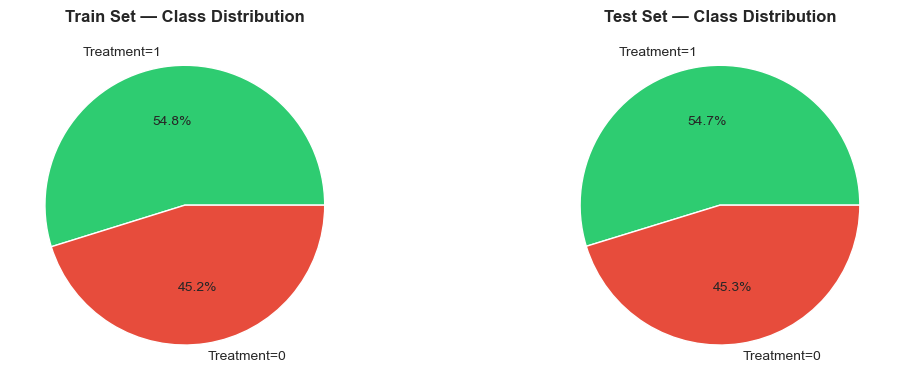

In [27]:
# Visualize train/test split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                             colors=['#2ecc71', '#e74c3c'], labels=['Treatment=1', 'Treatment=0'])
axes[0].set_title('Train Set — Class Distribution', fontweight='bold')
axes[0].set_ylabel('')

y_test.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                            colors=['#2ecc71', '#e74c3c'], labels=['Treatment=1', 'Treatment=0'])
axes[1].set_title('Test Set — Class Distribution', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Save Cleaned Dataset

In [28]:
folder_path = r"C:\Users\hp\Desktop\Mental health in tech"

df_merged.to_csv(f"{folder_path}\merged_clean.csv", index=False)
df_encoded.to_csv(f"{folder_path}\merged_encoded.csv", index=False)

print('Saved:')
print('  ../data/merged_clean.csv   — human-readable (before encoding)')
print('  ../data/merged_encoded.csv — model-ready (after encoding)')
print(f'\nFinal dataset: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns')
print(f'Features: {df_encoded.shape[1] - 1}')
print(f'Target: treatment (0=No, 1=Yes)')
print(f'\n✅ Preprocessing complete! → Next: 03_Modeling.ipynb')

Saved:
  ../data/merged_clean.csv   — human-readable (before encoding)
  ../data/merged_encoded.csv — model-ready (after encoding)

Final dataset: 2681 rows, 26 columns
Features: 25
Target: treatment (0=No, 1=Yes)

✅ Preprocessing complete! → Next: 03_Modeling.ipynb
